<a href="https://colab.research.google.com/github/Karan-Potdukhe/AI-ML-DL-Hacktoberfest2024-WB/blob/Karan-Potdukhe-patch-1/Main_11_Auto_encode_single_image_to_different_image_multi_file_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from matplotlib.pyplot import imshow
import numpy as np
import cv2
from keras.preprocessing.image import img_to_array
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Sequential
import os

In [ ]:
SIZE=256

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


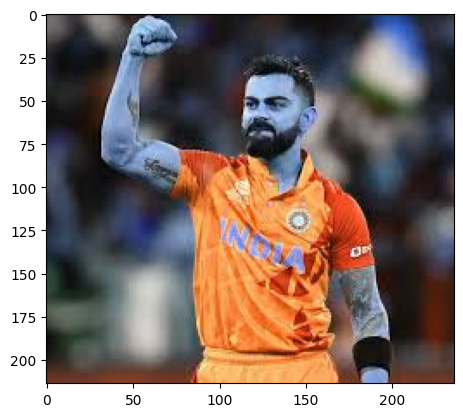

In [ ]:
from tqdm import tqdm
import cv2
from keras.preprocessing.image import img_to_array
from matplotlib.pyplot import imshow

img_data = []
path1 = '/content/virat.jpeg'

# Directly read the image instead of trying to list its contents
img = cv2.imread(path1, 1)  # Change 0 to 1 for color images
imshow(img)
img = cv2.resize(img, (SIZE, SIZE))
img_data.append(img_to_array(img))

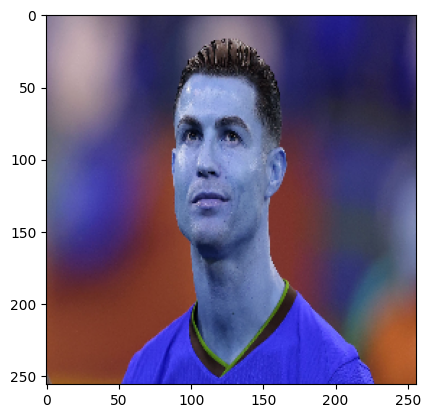

In [ ]:
img2_data=[]
path2 = '/content/ronaldo.jpg'
# path2 is an image file, not a directory

# Directly read and process the image
img = cv2.imread(path2, 1)  # Change 0 to 1 for color images
imshow(img)
img = cv2.resize(img, (SIZE, SIZE))
imshow(img)
img2_data.append(img_to_array(img))

# Remove the loop and os.listdir call as they are not needed for a single image

In [ ]:
img_array = np.reshape(img_data, (len(img_data), SIZE, SIZE, 3))
img_array = img_array.astype('float32') / 255.


In [ ]:
img_array2 = np.reshape(img2_data, (len(img2_data), SIZE, SIZE, 3))
img_array2 = img_array2.astype('float32') / 255.


In [ ]:
#Original einstein image for prediction as monalisa
#img_data3=[]

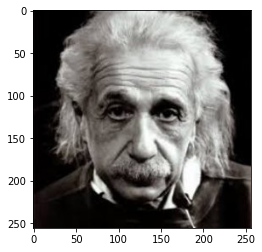

In [ ]:
img3=cv2.imread('/content/drive/MyDrive/KLA/einstein_original.jpg', 1)   #Change 0 to 1 for color images
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)#Changing BGR to RGB to show images in true colors
imshow(img3)
img3=cv2.resize(img3,(SIZE, SIZE))
img_data3.append(img_to_array(img3))

In [ ]:
img_array3 = np.reshape(img_data3, (len(img_data3), SIZE, SIZE, 3))
img_array3 = img_array3.astype('float32') / 255.

In [ ]:

import time
start=time.time()

In [ ]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(SIZE, SIZE, 3)))
model.add(MaxPooling2D((2, 2), padding='same'))
model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), padding='same'))
model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:

model.add(MaxPooling2D((2, 2), padding='same'))

In [ ]:
model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(3, (3, 3), activation='relu', padding='same'))

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)                    │ (None, 256, 256, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 128, 128, 8)         │           2,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 64, 64, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 64, 64, 8)           │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 32, 32, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 32, 32, 8)           │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_3 (UpSampling2D)       │ (None, 64, 64, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 64, 64, 8)           │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_4 (UpSampling2D)       │ (None, 128, 128, 8)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 128, 128, 32)        │           2,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_5 (UpSampling2D)       │ (None, 256, 256, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 256, 256, 3)         │             867 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,163 (31.89 KB)

 Trainable params: 8,163 (31.89 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
callbacks = [tf.keras.callbacks.TensorBoard(log_dir='einstein_logs')]

In [ ]:
model.fit(img_array, img_array2,
        epochs=500,
        shuffle=True,
        callbacks=callbacks)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.2167 - loss: 0.1702
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1359 - loss: 0.1679
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0993 - loss: 0.1642
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0847 - loss: 0.1587
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0846 - loss: 0.1503
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0930 - loss: 0.1388
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.1102 - loss: 0.1236
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1348 - loss: 0.1048
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.1934 - loss: 0.0833
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4128 - loss: 0.0630
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5759 - loss: 0.0507
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6518 - loss

In [ ]:
finish=time.time()
print('total_time = ', finish-start)

total_time =  355.4469647407532


In [ ]:
model.save('sachin_autoencoder.keras') # Change the file extension to .keras

In [ ]:
print("Output")
pred = model.predict(img_array)

Output
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 824ms/step


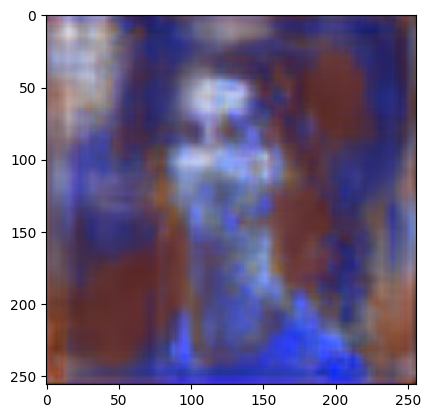

In [ ]:
imshow(pred[0].reshape(SIZE,SIZE,3))

In [ ]:
model.fit(img_array, img_array2,
        epochs=1000,
        shuffle=True,
        callbacks=callbacks)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9109 - loss: 0.0048
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9127 - loss: 0.0048
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9128 - loss: 0.0048
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9087 - loss: 0.0049
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9095 - loss: 0.0049
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9095 - loss: 0.0048
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9119 - loss: 0.0048
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9122 - loss: 0.0048
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9117 - loss: 0.0048
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9127 - loss: 0.0047
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9130 - loss: 0.0048
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accur

In [ ]:
finish=time.time()
print('total_time = ', finish-start)

total_time =  3035.2837221622467


In [ ]:
model.save('einstein_autoencoder.model')

INFO:tensorflow:Assets written to: einstein_autoencoder.model/assets


In [ ]:
print("Output")
pred = model.predict(img_array3)

Output


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


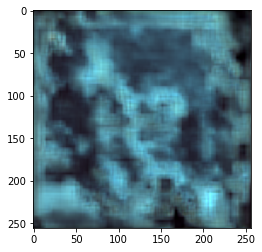

In [ ]:
imshow(pred[0].reshape(SIZE,SIZE,3))